---
title: "Lab 2: Avocado Prices"
author: "Shiqi Wu"
format:
  html:
    embed-resources: true
    code-fold: false
    include-in-header:
      text: |
        <style>
        .cell-output-display figure { max-width: 100%; }
        .cell-output-display img { max-width: 100%; height: auto; }
        </style>
---

## 0. Import the data and declare your package dependencies.

In [68]:
import pandas as pd

from plotnine import ggplot, aes, geom_boxplot, labs, geom_col, facet_wrap, scale_y_continuous, theme, element_text, geom_point

In [69]:
avocado = pd.read_csv("Data/avocado-updated-2020.csv")

In [70]:
avocado.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,2015,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,2015,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,2015,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,2015,Baltimore/Washington


## 1. Briefly describe the data set. What information does it contain?

In [71]:
avocado.shape

(33045, 13)

In [72]:
avocado.info()

<class 'pandas.DataFrame'>
RangeIndex: 33045 entries, 0 to 33044
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           33045 non-null  str    
 1   average_price  33045 non-null  float64
 2   total_volume   33045 non-null  float64
 3   4046           33045 non-null  float64
 4   4225           33045 non-null  float64
 5   4770           33045 non-null  float64
 6   total_bags     33045 non-null  float64
 7   small_bags     33045 non-null  float64
 8   large_bags     33045 non-null  float64
 9   xlarge_bags    33045 non-null  float64
 10  type           33045 non-null  str    
 11  year           33045 non-null  int64  
 12  geography      33045 non-null  str    
dtypes: float64(9), int64(1), str(3)
memory usage: 3.3 MB


In [73]:
avocado["year"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020])

In [74]:
avocado["type"].unique()

<StringArray>
['conventional', 'organic']
Length: 2, dtype: str

Answer: This dataset contains 33045 rows and 13 columns of weekly avocado sales data from 2015 to 2020. Each row shows sales for one date, geographical area, and avocado type: conventional or organic. It includes average prices, total sales volumes, and sales volumes for different avocado sizes and bag sizes.

## 2. Clean the data in any way you see fit.

In [75]:
avocado_clean = avocado.copy()

In [76]:
avocado_clean.head()

,date,average_price,total_volume,4046,4225,4770,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,2015,Albany
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,2015,Atlanta
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,2015,Atlanta
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,2015,Baltimore/Washington


In [77]:
avocado_clean["date"] = pd.to_datetime(avocado_clean["date"])

avocado_clean["date"].head()

0   2015-01-04
1   2015-01-04
2   2015-01-04
3   2015-01-04
4   2015-01-04
Name: date, dtype: datetime64[us]

In [78]:
avocado_clean.duplicated().sum()

np.int64(0)

In [79]:
avocado_clean["geography"].nunique()

54

In [80]:
sorted(avocado_clean["geography"].unique())

['Albany',
 'Atlanta',
 'Baltimore/Washington',
 'Boise',
 'Boston',
 'Buffalo/Rochester',
 'California',
 'Charlotte',
 'Chicago',
 'Cincinnati/Dayton',
 'Columbus',
 'Dallas/Ft. Worth',
 'Denver',
 'Detroit',
 'Grand Rapids',
 'Great Lakes',
 'Harrisburg/Scranton',
 'Hartford/Springfield',
 'Houston',
 'Indianapolis',
 'Jacksonville',
 'Las Vegas',
 'Los Angeles',
 'Louisville',
 'Miami/Ft. Lauderdale',
 'Midsouth',
 'Nashville',
 'New Orleans/Mobile',
 'New York',
 'Northeast',
 'Northern New England',
 'Orlando',
 'Philadelphia',
 'Phoenix/Tucson',
 'Pittsburgh',
 'Plains',
 'Portland',
 'Raleigh/Greensboro',
 'Richmond/Norfolk',
 'Roanoke',
 'Sacramento',
 'San Diego',
 'San Francisco',
 'Seattle',
 'South Carolina',
 'South Central',
 'Southeast',
 'Spokane',
 'St. Louis',
 'Syracuse',
 'Tampa',
 'Total U.S.',
 'West',
 'West Tex/New Mexico']

In [81]:
major_regions = ["California", "Great Lakes", "Midsouth", "Northeast", "Plains", "South Central", "Southeast", "West"]

major_regions

['California',
 'Great Lakes',
 'Midsouth',
 'Northeast',
 'Plains',
 'South Central',
 'Southeast',
 'West']

In [82]:
avocado_clean["geography_type"] = "unclassified"

avocado_clean[["geography", "geography_type"]].head()

,geography,geography_type
0,Albany,unclassified
1,Albany,unclassified
2,Atlanta,unclassified
3,Atlanta,unclassified
4,Baltimore/Washington,unclassified


In [83]:
avocado_clean.loc[avocado_clean["geography"] == "Total U.S.", "geography_type"] = "national"

In [84]:
avocado_clean.loc[avocado_clean["geography"] == "Total U.S.", ["geography", "geography_type"]].head()

,geography,geography_type
102,Total U.S.,national
103,Total U.S.,national
210,Total U.S.,national
211,Total U.S.,national
318,Total U.S.,national


In [85]:
avocado_clean.loc[avocado_clean["geography"].isin(major_regions), "geography_type"] = "major"

In [86]:
avocado_clean.loc[avocado_clean["geography_type"] == "major", "geography"].unique()

<StringArray>
[   'California',   'Great Lakes',      'Midsouth',     'Northeast',
        'Plains', 'South Central',     'Southeast',          'West']
Length: 8, dtype: str

In [87]:
sorted(avocado_clean.loc[avocado_clean["geography_type"] == "unclassified", "geography"].unique())

['Albany',
 'Atlanta',
 'Baltimore/Washington',
 'Boise',
 'Boston',
 'Buffalo/Rochester',
 'Charlotte',
 'Chicago',
 'Cincinnati/Dayton',
 'Columbus',
 'Dallas/Ft. Worth',
 'Denver',
 'Detroit',
 'Grand Rapids',
 'Harrisburg/Scranton',
 'Hartford/Springfield',
 'Houston',
 'Indianapolis',
 'Jacksonville',
 'Las Vegas',
 'Los Angeles',
 'Louisville',
 'Miami/Ft. Lauderdale',
 'Nashville',
 'New Orleans/Mobile',
 'New York',
 'Northern New England',
 'Orlando',
 'Philadelphia',
 'Phoenix/Tucson',
 'Pittsburgh',
 'Portland',
 'Raleigh/Greensboro',
 'Richmond/Norfolk',
 'Roanoke',
 'Sacramento',
 'San Diego',
 'San Francisco',
 'Seattle',
 'South Carolina',
 'Spokane',
 'St. Louis',
 'Syracuse',
 'Tampa',
 'West Tex/New Mexico']

In [88]:
other_regions = ["Northern New England", "South Carolina", "West Tex/New Mexico"]

other_regions

['Northern New England', 'South Carolina', 'West Tex/New Mexico']

In [89]:
avocado_clean.loc[avocado_clean["geography"].isin(other_regions), "geography_type"] = "other"

avocado_clean.loc[avocado_clean["geography_type"] == "other", "geography"].unique()

<StringArray>
['Northern New England', 'South Carolina', 'West Tex/New Mexico']
Length: 3, dtype: str

In [90]:
avocado_clean.loc[avocado_clean["geography_type"] == "unclassified", "geography_type"] = "metro"

avocado_clean.groupby("geography_type")["geography"].nunique()

geography_type
major        8
metro       42
national     1
other        3
Name: geography, dtype: int64

In [91]:
avocado_clean = avocado_clean.rename(columns={"4046": "small_hass", "4225": "large_hass", "4770": "xlarge_hass"})

avocado_clean.columns

Index(['date', 'average_price', 'total_volume', 'small_hass', 'large_hass',
       'xlarge_hass', 'total_bags', 'small_bags', 'large_bags', 'xlarge_bags',
       'type', 'year', 'geography', 'geography_type'],
      dtype='str')

Answer: I converted the date column to datetime format and renamed the three avocado size columns. I found no missing values or duplicate rows. I classified the 54 geographical areas into 8 major regions, 42 metro areas, 1 national total, and 3 other areas. Some geographical areas overlap, so their sales volumes should not be added together.

## 3. Which major geographical region sold the most total organic, small Hass avocados in 2017?

In [92]:
organic_2017 = avocado_clean.loc[(avocado_clean["year"] == 2017) & (avocado_clean["type"] == "organic") & (avocado_clean["geography_type"] == "major")]

organic_2017.head()

,date,average_price,total_volume,small_hass,large_hass,xlarge_hass,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography,geography_type
11244,2017-01-01,1.46,164137.04,31267.65,65430.27,6.16,67432.96,50963.98,16468.98,0.0,organic,2017,California,major
11262,2017-01-01,1.44,104153.91,4104.86,69800.29,0.00,30248.76,23593.03,6655.73,0.0,organic,2017,Great Lakes,major
11282,2017-01-01,1.72,72287.79,3353.64,36090.72,1813.60,31029.83,29203.33,1826.50,0.0,organic,2017,Midsouth,major
11290,2017-01-01,2.00,115256.09,9132.13,36276.39,923.53,68924.04,65447.53,3476.51,0.0,organic,2017,Northeast,major
11302,2017-01-01,1.62,47042.21,4547.17,15245.73,1366.36,25882.95,17253.74,8629.21,0.0,organic,2017,Plains,major


In [93]:
small_hass_totals = organic_2017.groupby("geography")["small_hass"].sum().sort_values(ascending=False)

small_hass_totals

geography
West             1870206.29
South Central    1717104.19
California       1526290.58
Northeast         925832.36
Southeast         285124.34
Great Lakes       202487.68
Midsouth          186395.50
Plains            168583.40
Name: small_hass, dtype: float64

Answer: The West region sold the most organic small Hass avocados in 2017, with a total sales volume of 1870206.29.

## 4. Split the date variable into month, day, and year variables. In which month is the highest average volume of avocado sales?

In [94]:
avocado_clean["month"] = avocado_clean["date"].dt.month
avocado_clean["day"] = avocado_clean["date"].dt.day
avocado_clean["year"] = avocado_clean["date"].dt.year

In [95]:
avocado_clean[["date", "month", "day", "year"]].head()

,date,month,day,year
0,2015-01-04,1,4,2015
1,2015-01-04,1,4,2015
2,2015-01-04,1,4,2015
3,2015-01-04,1,4,2015
4,2015-01-04,1,4,2015


In [96]:
national_sales = avocado_clean.loc[avocado_clean["geography"] == "Total U.S."]

national_sales.head()

,date,average_price,total_volume,small_hass,large_hass,xlarge_hass,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography,geography_type,month,day
102,2015-01-04,0.95,31324277.73,12357161.34,13624083.05,844093.32,4498940.02,3585321.58,894945.63,18672.81,conventional,2015,Total U.S.,national,1,4
103,2015-01-04,1.46,612910.15,233286.13,216611.20,4370.99,158641.83,115068.71,43573.12,0.00,organic,2015,Total U.S.,national,1,4
210,2015-01-11,1.01,29063542.75,11544810.53,12134773.38,866574.66,4517384.18,3783261.16,718333.87,15789.15,conventional,2015,Total U.S.,national,1,11
211,2015-01-11,1.42,669528.88,270966.74,260971.60,3830.42,133760.12,106844.49,26915.63,0.00,organic,2015,Total U.S.,national,1,11
318,2015-01-18,1.03,29043458.85,11858139.34,11701947.80,831301.90,4652069.81,3873041.26,771093.20,7935.35,conventional,2015,Total U.S.,national,1,18


In [97]:
weekly_sales = national_sales.groupby(["date", "month"], as_index=False)["total_volume"].sum()

weekly_sales.head()

,date,month,total_volume
0,2015-01-04,1,31937187.88
1,2015-01-11,1,29733071.63
2,2015-01-18,1,29756578.85
3,2015-01-25,1,29026679.70
4,2015-02-01,2,45396358.48


In [99]:
monthly_average = weekly_sales.groupby("month")["total_volume"].mean().sort_values(ascending=False)

monthly_average

month
5     4.586407e+07
2     4.473581e+07
6     4.289893e+07
4     4.154321e+07
3     4.071280e+07
1     4.022865e+07
7     4.019392e+07
8     3.877131e+07
9     3.694878e+07
10    3.439165e+07
11    3.347303e+07
12    3.291192e+07
Name: total_volume, dtype: float64

Answer: May had the highest average weekly avocado sales volume. I used the Total U.S. records to avoid double-counting overlapping regions, combined organic and conventional sales for each week, and then calculated the average by month across all years.

## 5. Which metro area geographical regions sold the most total avocados? Plot side-by-side box-plots of the total volume for only the five metro geographical regions with the highest averages for the total_volume variable.

In [100]:
metro_sales = avocado_clean.loc[avocado_clean["geography_type"] == "metro"]

metro_sales.head()

,date,average_price,total_volume,small_hass,large_hass,xlarge_hass,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography,geography_type,month,day
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,metro,1,4
1,2015-01-04,1.79,1373.95,57.42,153.88,0.00,1162.65,1162.65,0.00,0.0,organic,2015,Albany,metro,1,4
2,2015-01-04,1.00,435021.49,364302.39,23821.16,82.15,46815.79,16707.15,30108.64,0.0,conventional,2015,Atlanta,metro,1,4
3,2015-01-04,1.76,3846.69,1500.15,938.35,0.00,1408.19,1071.35,336.84,0.0,organic,2015,Atlanta,metro,1,4
4,2015-01-04,1.08,788025.06,53987.31,552906.04,39995.03,141136.68,137146.07,3990.61,0.0,conventional,2015,Baltimore/Washington,metro,1,4


In [101]:
top_five_metros = metro_sales.groupby("geography")["total_volume"].mean().sort_values(ascending=False).head(5)

top_five_metros

geography
Los Angeles         1.567566e+06
New York            8.631458e+05
Dallas/Ft. Worth    7.127519e+05
Houston             6.876533e+05
Phoenix/Tucson      6.250383e+05
Name: total_volume, dtype: float64

In [102]:
top_five_sales = metro_sales.loc[metro_sales["geography"].isin(top_five_metros.index)]

top_five_sales.head()

,date,average_price,total_volume,small_hass,large_hass,xlarge_hass,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography,geography_type,month,day
22,2015-01-04,0.74,1086363.97,612795.80,374420.68,9817.28,89330.21,54563.33,34760.08,6.80,conventional,2015,Dallas/Ft. Worth,metro,1,4
23,2015-01-04,1.35,9895.96,4634.70,1647.92,0.00,3613.34,3613.34,0.00,0.00,organic,2015,Dallas/Ft. Worth,metro,1,4
36,2015-01-04,0.71,1062990.62,506426.58,436347.57,4378.92,115837.55,90299.85,25537.70,0.00,conventional,2015,Houston,metro,1,4
37,2015-01-04,1.22,8938.32,7009.77,671.88,0.00,1256.67,1256.67,0.00,0.00,organic,2015,Houston,metro,1,4
44,2015-01-04,0.85,2682159.95,1837999.65,524430.47,64225.78,255504.05,215571.80,36981.72,2950.53,conventional,2015,Los Angeles,metro,1,4


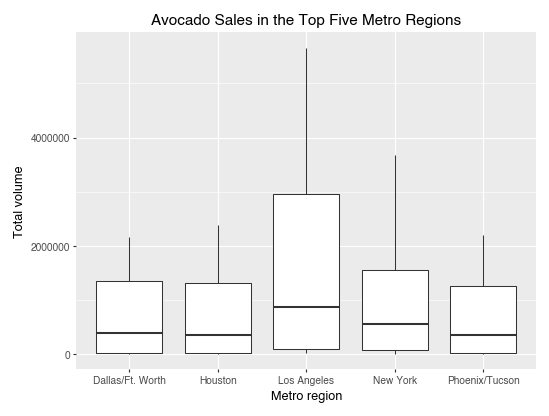

In [103]:
ggplot(top_five_sales, aes(x="geography", y="total_volume")) + geom_boxplot() + labs(x="Metro region", y="Total volume", title="Avocado Sales in the Top Five Metro Regions")

Answer: Los Angeles had the highest average total sales volume, followed by New York, the Dallas and Fort Worth region, Houston, and the Phoenix and Tucson region. The boxplots show the distribution of total sales volume for these five metro regions.

## 6. From your cleaned data set, create a data set with only these California regions and answer the following questions about these California regions only.

In [104]:
california_regions = ["Los Angeles", "San Diego", "Sacramento", "San Francisco"]

california_regions

['Los Angeles', 'San Diego', 'Sacramento', 'San Francisco']

In [105]:
california_sales = avocado_clean.loc[avocado_clean["geography"].isin(california_regions)].copy()

california_sales.head()

,date,average_price,total_volume,small_hass,large_hass,xlarge_hass,total_bags,small_bags,large_bags,xlarge_bags,type,year,geography,geography_type,month,day
44,2015-01-04,0.85,2682159.95,1837999.65,524430.47,64225.78,255504.05,215571.80,36981.72,2950.53,conventional,2015,Los Angeles,metro,1,4
45,2015-01-04,1.25,54495.54,47721.51,1723.40,0.00,5050.63,5050.63,0.00,0.00,organic,2015,Los Angeles,metro,1,4
80,2015-01-04,1.05,430138.88,110693.69,270107.61,9737.50,39600.08,39600.08,0.00,0.00,conventional,2015,Sacramento,metro,1,4
81,2015-01-04,1.33,9213.49,3727.52,4327.52,0.00,1158.45,1158.45,0.00,0.00,organic,2015,Sacramento,metro,1,4
82,2015-01-04,0.94,461607.33,244152.26,165299.33,15302.75,36852.99,30884.29,5595.00,373.70,conventional,2015,San Diego,metro,1,4


## 7. In which California regions is the price of organic versus conventional avocados most different? Support your answer with a few summary statistics AND a visualization.

In [106]:
california_prices = california_sales.groupby(["geography", "type"], as_index=False)["average_price"].mean()

california_prices

,geography,type,average_price
0,Los Angeles,conventional,1.047124
1,Los Angeles,organic,1.574902
2,Sacramento,conventional,1.295359
3,Sacramento,organic,1.873856
4,San Diego,conventional,1.113856
5,San Diego,organic,1.798366
6,San Francisco,conventional,1.400490
7,San Francisco,organic,2.119444


In [107]:
price_comparison = california_prices.pivot(index="geography", columns="type", values="average_price")

price_comparison

type,conventional,organic
geography,,
Los Angeles,1.047124,1.574902
Sacramento,1.295359,1.873856
San Diego,1.113856,1.798366
San Francisco,1.400490,2.119444


In [108]:
price_comparison["price_difference"] = price_comparison["organic"] - price_comparison["conventional"]

price_comparison

type,conventional,organic,price_difference
geography,,,
Los Angeles,1.047124,1.574902,0.527778
Sacramento,1.295359,1.873856,0.578497
San Diego,1.113856,1.798366,0.684510
San Francisco,1.400490,2.119444,0.718954


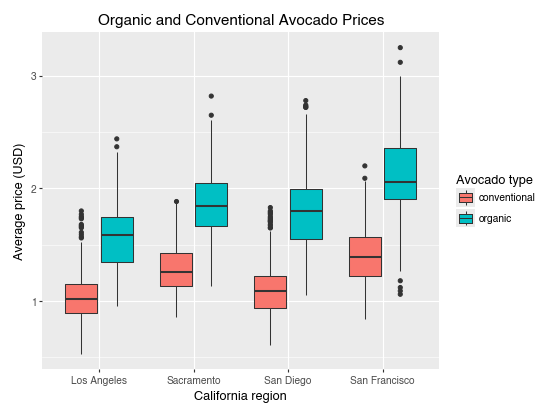

In [109]:
ggplot(california_sales, aes(x="geography", y="average_price", fill="type")) + geom_boxplot() + labs(x="California region", y="Average price (USD)", fill="Avocado type", title="Organic and Conventional Avocado Prices")

Answer: San Francisco had the largest difference in average prices. Organic avocados averaged 2.12 dollars, compared with 1.40 dollars for conventional avocados, a difference of about 0.72 dollars. San Diego had the second-largest difference at about 0.68 dollars, followed by Sacramento at 0.58 dollars and Los Angeles at 0.53 dollars. The boxplots show that organic avocado prices were generally higher in all four regions.

## 8. The following plot shows, for all four California regions, the proportion of the average Hass avocado sales that are small, large, or extra large; conventional vs. organic. Recreate the plot; you do not have to replicate the exact finishing touches - e.g., color, theme - but your plot should resemble the content of this plot.

In [110]:
hass_average = california_sales.groupby(["geography", "type"], as_index=False)[["small_hass", "large_hass", "xlarge_hass"]].mean()

hass_average

,geography,type,small_hass,large_hass,xlarge_hass
0,Los Angeles,conventional,1.172952e+06,443842.308562,97073.643529
1,Los Angeles,organic,1.444206e+04,20804.220654,6.035294
2,Sacramento,conventional,1.412831e+05,243005.070163,6333.279673
3,Sacramento,organic,2.808893e+03,4282.693203,0.772680
4,San Diego,conventional,1.637928e+05,140106.101438,17963.543497
5,San Diego,organic,2.573068e+03,7273.784575,1.323595
6,San Francisco,conventional,2.158398e+05,449377.420359,14931.603235
7,San Francisco,organic,8.303041e+03,11350.098072,2.159346


In [111]:
hass_long = hass_average.melt(id_vars=["geography", "type"], value_vars=["small_hass", "large_hass", "xlarge_hass"], var_name="size", value_name="average_volume")

hass_long.head()

,geography,type,size,average_volume
0,Los Angeles,conventional,small_hass,1.172952e+06
1,Los Angeles,organic,small_hass,1.444206e+04
2,Sacramento,conventional,small_hass,1.412831e+05
3,Sacramento,organic,small_hass,2.808893e+03
4,San Diego,conventional,small_hass,1.637928e+05


In [112]:
hass_long["total_hass"] = hass_long.groupby(["geography", "type"])["average_volume"].transform("sum")

hass_long.head()

,geography,type,size,average_volume,total_hass
0,Los Angeles,conventional,small_hass,1.172952e+06,1.713868e+06
1,Los Angeles,organic,small_hass,1.444206e+04,3.525232e+04
2,Sacramento,conventional,small_hass,1.412831e+05,3.906215e+05
3,Sacramento,organic,small_hass,2.808893e+03,7.092359e+03
4,San Diego,conventional,small_hass,1.637928e+05,3.218624e+05


In [113]:
hass_long["proportion"] = hass_long["average_volume"] / hass_long["total_hass"]

hass_long.head()

,geography,type,size,average_volume,total_hass,proportion
0,Los Angeles,conventional,small_hass,1.172952e+06,1.713868e+06,0.684389
1,Los Angeles,organic,small_hass,1.444206e+04,3.525232e+04,0.409677
2,Sacramento,conventional,small_hass,1.412831e+05,3.906215e+05,0.361688
3,Sacramento,organic,small_hass,2.808893e+03,7.092359e+03,0.396045
4,San Diego,conventional,small_hass,1.637928e+05,3.218624e+05,0.508891


In [114]:
hass_long.groupby(["geography", "type"])["proportion"].sum()

geography      type        
Los Angeles    conventional    1.0
               organic         1.0
Sacramento     conventional    1.0
               organic         1.0
San Diego      conventional    1.0
               organic         1.0
San Francisco  conventional    1.0
               organic         1.0
Name: proportion, dtype: float64

In [115]:
hass_long["size"] = hass_long["size"].replace({"small_hass": "Small", "large_hass": "Large", "xlarge_hass": "Xlarge"})

hass_long["size"].unique()

<StringArray>
['Small', 'Large', 'Xlarge']
Length: 3, dtype: str

In [116]:
hass_long["size"] = pd.Categorical(hass_long["size"], categories=["Xlarge", "Large", "Small"], ordered=True)

hass_long["size"].cat.categories

Index(['Xlarge', 'Large', 'Small'], dtype='str')

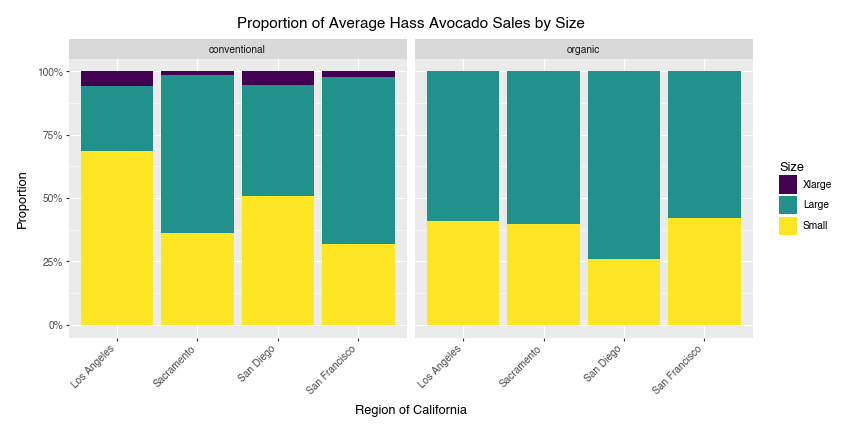

In [117]:
hass_plot = ggplot(hass_long, aes(x="geography", y="proportion", fill="size")) + geom_col() + facet_wrap("~type", nrow=1) + theme(axis_text_x=element_text(rotation=45, ha="right"), figure_size=(10, 5))
hass_plot = hass_plot + scale_y_continuous(breaks=[0, 0.25, 0.5, 0.75, 1], labels=["0%", "25%", "50%", "75%", "100%"])
hass_plot = hass_plot + labs(x="Region of California", y="Proportion", fill="Size", title="Proportion of Average Hass Avocado Sales by Size")

hass_plot

## Using Outside Data

A joke in the media is that Millennials can’t afford houses, because they spend all their money buying avocado toast. Let’s use this data set to address that claim.

Find or assemble a data set of real data, with house prices for these four California regions. Join this data set with your California avocado data set.

Use your new joined data set to make an argument about the relationship between house prices and avocado prices/sales.

Support your argument with a plot.

Data source and method: I used monthly Zillow Home Value Index data which is "ZHVI" from “https://www.zillow.com/research/data/” for the Los Angeles, San Diego, Sacramento, and San Francisco metro areas from 2015 to 2020. ZHVI measures typical home values rather than average sale prices. I calculated monthly average avocado prices separately for conventional and organic avocados and joined the data by region, year, and month. The Zillow metro areas may not have exactly the same boundaries as the avocado sales regions.

In [118]:
housing = pd.read_csv("Data/Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv")

housing.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28,2026-03-31,2026-04-30,2026-05-31,2026-06-30,2026-07-31
0,102001,0,United States,country,NaN,124760.353386,124979.846843,125252.051048,125835.875637,126507.787743,...,368600.830990,369290.109714,370096.503345,370865.855786,371594.025445,372094.225425,372175.152586,371910.603335,371664.627433,371774.013984
1,394913,1,"New York, NY",msa,NY,221730.961420,222673.192902,223624.151144,225551.160519,227546.645459,...,711084.998310,714481.548049,717957.123329,721070.448456,724701.411953,728550.827603,730998.279366,732547.901292,734053.602437,737078.239973
2,753899,2,"Los Angeles, CA",msa,CA,225112.633581,225950.338198,227066.152759,229286.248907,231714.338088,...,958467.862334,961838.271934,965861.431836,968431.823262,969683.356261,969344.133347,967696.188085,966216.924715,964714.939801,964933.539367
3,394463,3,"Chicago, IL",msa,IL,158537.235557,158683.994854,158963.500519,159658.841153,160495.252299,...,347939.585960,349538.582140,351328.450802,353002.256461,354806.848210,356259.214604,357291.377201,357923.452730,358804.309842,360261.570973
4,394514,4,"Dallas, TX",msa,TX,131282.417502,131340.891150,131408.112593,131582.679622,131812.841469,...,372246.711434,371975.510588,371751.570814,371305.648235,370713.999305,369629.029256,368279.710153,366682.370547,365420.503097,364792.581562


In [119]:
housing.loc[housing["StateName"] == "CA", ["RegionName", "RegionType"]]

,RegionName,RegionType
2,"Los Angeles, CA",msa
12,"San Francisco, CA",msa
13,"Riverside, CA",msa
17,"San Diego, CA",msa
26,"Sacramento, CA",msa
35,"San Jose, CA",msa
56,"Fresno, CA",msa
62,"Bakersfield, CA",msa
70,"Oxnard, CA",msa
75,"Stockton, CA",msa


In [120]:
housing_ca = housing.loc[housing["RegionName"].isin(["Los Angeles, CA", "San Diego, CA", "Sacramento, CA", "San Francisco, CA"])].copy()

housing_ca[["RegionName", "StateName"]]

,RegionName,StateName
2,"Los Angeles, CA",CA
12,"San Francisco, CA",CA
17,"San Diego, CA",CA
26,"Sacramento, CA",CA


In [121]:
housing_long = housing_ca.melt(id_vars=["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"], var_name="date", value_name="home_value")

housing_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,date,home_value
0,753899,2,"Los Angeles, CA",msa,CA,2000-01-31,225112.633581
1,395057,12,"San Francisco, CA",msa,CA,2000-01-31,291775.548547
2,395056,17,"San Diego, CA",msa,CA,2000-01-31,217544.190397
3,395045,26,"Sacramento, CA",msa,CA,2000-01-31,171939.881302
4,753899,2,"Los Angeles, CA",msa,CA,2000-02-29,225950.338198


In [122]:
housing_long["date"] = pd.to_datetime(housing_long["date"])

housing_long["date"].head()

0   2000-01-31
1   2000-01-31
2   2000-01-31
3   2000-01-31
4   2000-02-29
Name: date, dtype: datetime64[us]

In [123]:
housing_long["year"] = housing_long["date"].dt.year
housing_long["month"] = housing_long["date"].dt.month

housing_long[["date", "year", "month"]].head()

,date,year,month
0,2000-01-31,2000,1
1,2000-01-31,2000,1
2,2000-01-31,2000,1
3,2000-01-31,2000,1
4,2000-02-29,2000,2


In [124]:
housing_period = housing_long.loc[(housing_long["year"] >= 2015) & (housing_long["year"] <= 2020)].copy()

housing_period["year"].unique()

array([2015, 2016, 2017, 2018, 2019, 2020], dtype=int32)

In [125]:
housing_period["geography"] = housing_period["RegionName"].str.replace(", CA", "", regex=False)

housing_period[["RegionName", "geography"]].drop_duplicates()

,RegionName,geography
720,"Los Angeles, CA",Los Angeles
721,"San Francisco, CA",San Francisco
722,"San Diego, CA",San Diego
723,"Sacramento, CA",Sacramento


In [126]:
housing_monthly = housing_period[["geography", "year", "month", "home_value"]].copy()

housing_monthly.head()

,geography,year,month,home_value
720,Los Angeles,2015,1,514205.196544
721,San Francisco,2015,1,668175.136659
722,San Diego,2015,1,462294.901805
723,Sacramento,2015,1,321039.331302
724,Los Angeles,2015,2,515997.139443


In [127]:
avocado_monthly = california_sales.groupby(["geography", "year", "month", "type"], as_index=False)["average_price"].mean()

avocado_monthly.head()

,geography,year,month,type,average_price
0,Los Angeles,2015,1,conventional,0.8875
1,Los Angeles,2015,1,organic,1.2125
2,Los Angeles,2015,2,conventional,0.8250
3,Los Angeles,2015,2,organic,1.3000
4,Los Angeles,2015,3,conventional,0.9120


In [128]:
avocado_housing = avocado_monthly.merge(housing_monthly, on=["geography", "year", "month"], how="left", validate="many_to_one")

avocado_housing.head()

,geography,year,month,type,average_price,home_value
0,Los Angeles,2015,1,conventional,0.8875,514205.196544
1,Los Angeles,2015,1,organic,1.2125,514205.196544
2,Los Angeles,2015,2,conventional,0.8250,515997.139443
3,Los Angeles,2015,2,organic,1.3000,515997.139443
4,Los Angeles,2015,3,conventional,0.9120,516379.159037


In [129]:
avocado_housing[["average_price", "home_value"]].isna().sum()

average_price    0
home_value       0
dtype: int64

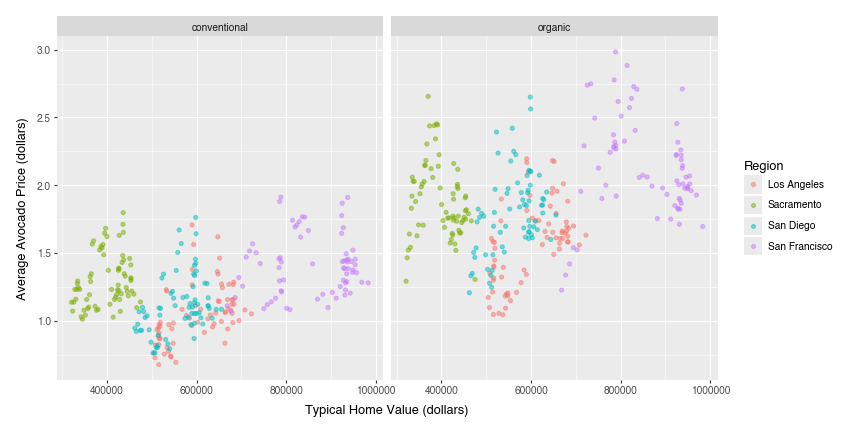

In [130]:
housing_plot = ggplot(avocado_housing, aes(x="home_value", y="average_price", color="geography")) + geom_point(alpha=0.5) + facet_wrap("~type", nrow=1) + labs(x="Typical Home Value (dollars)", y="Average Avocado Price (dollars)", color="Region") + theme(figure_size=(10, 5))

housing_plot

Answer: The scatterplots do not show a consistent relationship between home values and avocado prices across the four regions. San Francisco generally had higher home values and higher avocado prices, but Sacramento had lower home values without consistently having the lowest avocado prices. Organic avocados were generally more expensive than conventional avocados. These data do not support the claim that buying avocado toast prevents Millennials from buying homes, because they do not measure individual spending or home purchases and cannot establish causation.